In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

## Load Model and Adapter

In [2]:
from unsloth.chat_templates import get_chat_template
from unsloth import FastModel
import torch

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct-unsloth-bnb-4bit",
    dtype = None, # None for auto detection
    max_seq_length = 1024, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
)

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.21: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 2.335 GiB
no_split classes   : ['LlamaDecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.342 GiB
activation reserve : 11.649 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.98 GiB  weights  1.324 GiB  free 11.654 GiB  reserve 11.649 GiB
  cuda:1  budget  13.00 GiB  weights  1.011 GiB  free 11.985 GiB  reserve 11.487 GiB   <- outpu

## Apply Adapter

In [ ]:
from peft import PeftModel
model = PeftModel.from_pretrained(
    model,
    "riskfolioAdapter",
    is_trainable=True
)

In [4]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.562 GB.
4.188 GB of memory reserved.


## Function Definitions

In [5]:
!pip install Riskfolio-Lib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.3/455.3 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 85.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 106.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 98.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.5/316.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 32.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting un

In [6]:
# global variables 
last_distribution = None
last_rm = None
last_port = None

In [ ]:
import os
import pandas as pd 
import riskfolio as rp
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="cvxpy")


def get_file_names(folder):
    return [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]


def extractingInformation(response): 
    # GET RISK MEASURE
    riskMeasure = None
    lines = response.split("\n")
    for line in lines: 
        if("-based risk measure" in line): riskMeasure = line.split("-based risk measure")[0].split(" ")[-1]
    
    # GET STOCKS 
    stock_list = []
    stock_phrase = "following stock tickers: "
    if(stock_phrase in response): # list of stocks 
        # get list of stocks
        lines = response.split("\n")
        for line in lines: 
            if(stock_phrase in line): 
                stock_list = line.split(stock_phrase)[-1]
                stock_list = stock_list.split(", ")
                break
    elif("following qualities:" in response): # list of qualities
        # get list of qualities
        lines = response.split("\n")
        sectors = None
        dividend = None
        PE = None 
        for line in lines: 
            if("sectors: " in line): sectors = line.split("sectors: ")[-1].split(", ")
            if("Dividend rate above" in line): dividend = float(line.split("Dividend rate above")[-1][:-1])
            if("PE ratio below " in line): PE = int(line.split("PE ratio below ")[-1])

        # get tickers by qualities
        table = pd.read_csv("fundamentals.csv")
        # filter by tickers with data 
        file_names = [itm[:-4] for itm in get_file_names("yf-downloads")]
        table = table[table["Symbol"].isin(file_names)].copy()
        # filtering by sector 
        if(sectors):    table = table[table["Sector"].isin(sectors)].copy()
        if(dividend):   table = table[table["Dividend Yield"] > dividend].copy()
        if(PE):         table = table[table["Price/Earnings"] < PE].copy()
        stock_list = table["Symbol"].to_list()
    # return info 
    return stock_list, riskMeasure


def getReturns(symbols): 
    start_date = "2021-01-01"
    series_set = []
    for s in symbols: 
        # Get Data
        df = pd.read_csv(f"yf-downloads/{s}.csv")
        # Extract Date and Adj Close
        df = df[["Price", "Adj Close"]][2:]
        df.rename(columns={"Price": "Date"}, inplace=True)
        df = df[df['Date'] > start_date].reset_index(drop=True)
        df["Date"] = pd.to_datetime(df["Date"])
        # Save Series
        series = df.set_index("Date")["Adj Close"]
        series.name = s
        series_set.append(series)
    lens = [len(series) for series in series_set]
    max_len = max(lens)
    series_set2 = [series for series in series_set if len(series) == max_len]
    adj_close = pd.concat(series_set2, axis=1)
    returns = adj_close.astype(float).pct_change().dropna()
    return returns


def getOptimalAllocation(symbols, rm): 
    global last_distribution, last_port
    returns = getReturns(symbols)
    port = rp.Portfolio(returns=returns)
    last_port = port
    method_mu='hist' # Method to estimate expected returns based on historical data.
    method_cov='hist' # Method to estimate covariance matrix based on historical data.
    port.assets_stats(method_mu=method_mu, method_cov=method_cov)
    model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
    obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
    hist = True # Use historical scenarios for risk measures that depend on scenarios
    rf = 0 # Risk free rate
    l = 0 # Risk aversion factor, only useful when obj is 'Utility'
    w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)
    last_distribution = w 
    return w


def generateResponse(stock_list, riskMeasure): 
    global last_rm
    if(len(stock_list) == 0): 
        return "No stocks met your qualifications."

    rm = 'MV' # Risk measure used
    if(riskMeasure == "dispersion"): rm = 'MV'
    if(riskMeasure == "downside"):   rm = 'MSV'
    last_rm = rm

    w = getOptimalAllocation(stock_list, rm)
    df = pd.DataFrame({"ticker": w.index, "weight": w["weights"].to_list()})
    df = df[df["weight"] > 0.02]
    df = df.sort_values("weight", ascending=False)
    
    response = "Here is the optimal portfolio distribution:"
    for i in range(len(df)): 
        row = df.iloc[i]
        ticker = row["ticker"]
        weight = row["weight"]
        response += f"\n\t{ticker.ljust(5)}\t{int(weight*100)}%"    
    return response

def follow_up(response): 
    stock_list, riskMeasure = extractingInformation(response)
    return generateResponse(stock_list, riskMeasure) 


## Inference

In [8]:

def processCommand(cmd):
    cmd = cmd.strip()
    if(cmd == "plot allocation" and last_distribution is not None): 
        ax = rp.plot_pie(w=last_distribution, title='Optimal Portfolio Distribution', others=0.05, nrow=25, cmap = "tab20", height=6, width=10, ax=None)
    elif(cmd == "plot frontier" and last_port is not None): 
        frontier = last_port.efficient_frontier(model='Classic', rm=last_rm, points=50, rf=0.03, hist=True)
        label = 'Optimal Portfolio' # Title of point
        mu = last_port.mu # Expected returns
        cov = last_port.cov # Covariance matrix
        returns = last_port.returns # Returns of the assets
        ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=last_rm,
                              rf=0.03, alpha=0.05, cmap='viridis', w=last_distribution, label=label,
                              marker='*', s=16, c='r', height=6, width=10, ax=None)
    elif(cmd == "plot frontier area" and (last_port is not None) and (last_rm is not None)): 
        frontier = last_port.efficient_frontier(model='Classic', rm=last_rm, points=50, rf=0.03, hist=True)
        ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)
    else: 
        print("No portfolio has been optimized in the past.")

        
def Respond(query): 
    # Respond to Commands (starting with !)
    if(query[0] == '!'):
        processCommand(query[1:])
        return
    
    # Get response from LLM
    messages = [{"role": "user", "content": query}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True, # Must add for generation
        return_tensors = "pt",
        tokenize = True,
        return_dict = True,
    ).to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens = 128, # Increase for longer outputs!
        temperature = 0.01, top_p = 0.95, top_k = 64,
    )
    result = tokenizer.batch_decode(outputs)
    response = result[0].split("assistant<|end_header_id|>")[-1][:-10]

    ## Get followup response 
    return response, follow_up(response)


In [9]:
query = "Please make for me an optimized stock portfolio using the following tickers: AAPL, NVDA, MSFT, ALLE, ALGN, AMG, AET, AES. I would like the portfolio to be optimized to reduce dispersion."
print(query)
response, followup = Respond(query)
print()
print(response)
print("Applying Riskfolio Library...")
print(followup)

Please make for me an optimized stock portfolio using the following tickers: AAPL, NVDA, MSFT, ALLE, ALGN, AMG, AET, AES. I would like the portfolio to be optimized to reduce dispersion.



Sure, I'll generate an optimized stock portfolio for you.
The portfolio will consist of the following stock tickers: AAPL, NVDA, MSFT, ALLE, ALGN, AMG, AET, AES
Portfolio will be optimized using a dispersion-based risk measure.
**Disclaimer:** AI-generated information is provided for educational purposes only and should not be considered financial advice.
Applying Riskfolio Library...
Here is the optimal portfolio distribution:
	NVDA 	58%
	AMG  	37%
	AAPL 	4%


In [10]:
query = "Please find stocks in the utilites, technology, and healthcare sectors, to make an optimal portfolio to minimize potential downsides. I would also like these stocks to have a diviend rate higher than 3% and a PE ratio less than 40. "
print(query)
response, followup = Respond(query)
print()
print(response)
print("Applying Riskfolio Library...")
print(followup)

Please find stocks in the utilites, technology, and healthcare sectors, to make an optimal portfolio to minimize potential downsides. I would also like these stocks to have a diviend rate higher than 3% and a PE ratio less than 40. 



Absolutely, I can generate the portfolio you're looking for.
The portfolio will contain stocks with the following qualities:
	Belonging to the following sectors: Utilities, Technology, Healthcare
	Dividend rate above 3.0%
	PE ratio below 40
Portfolio will be optimized using a downside-based risk measure.
**Disclaimer:** AI-generated information is provided for educational purposes only and should not be considered financial advice.
Applying Riskfolio Library...
Here is the optimal portfolio distribution:
	ETR  	59%
	FE   	21%
	CNP  	12%
	NI   	7%


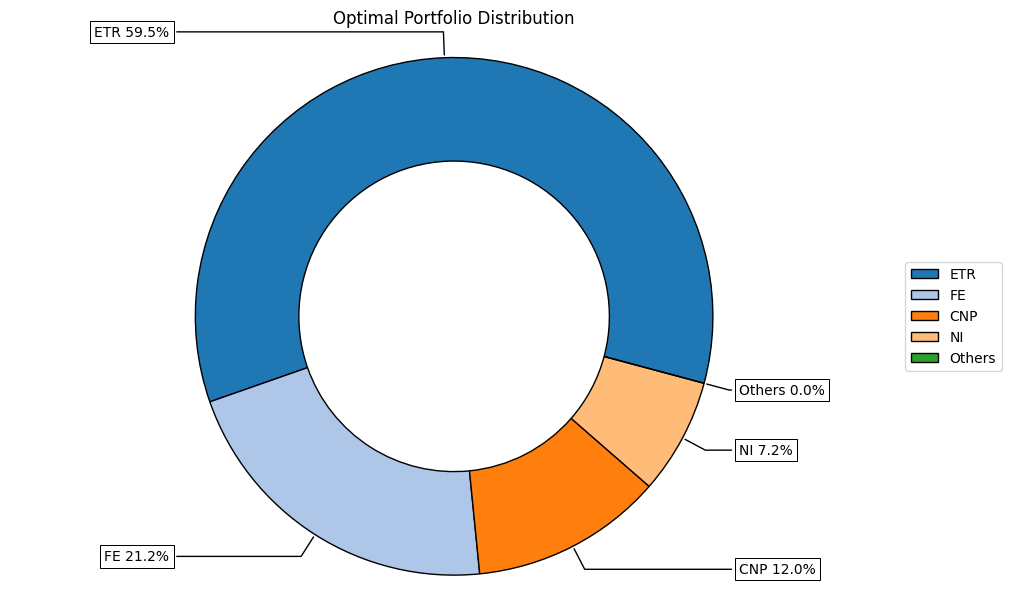

In [11]:
Respond("!plot allocation")

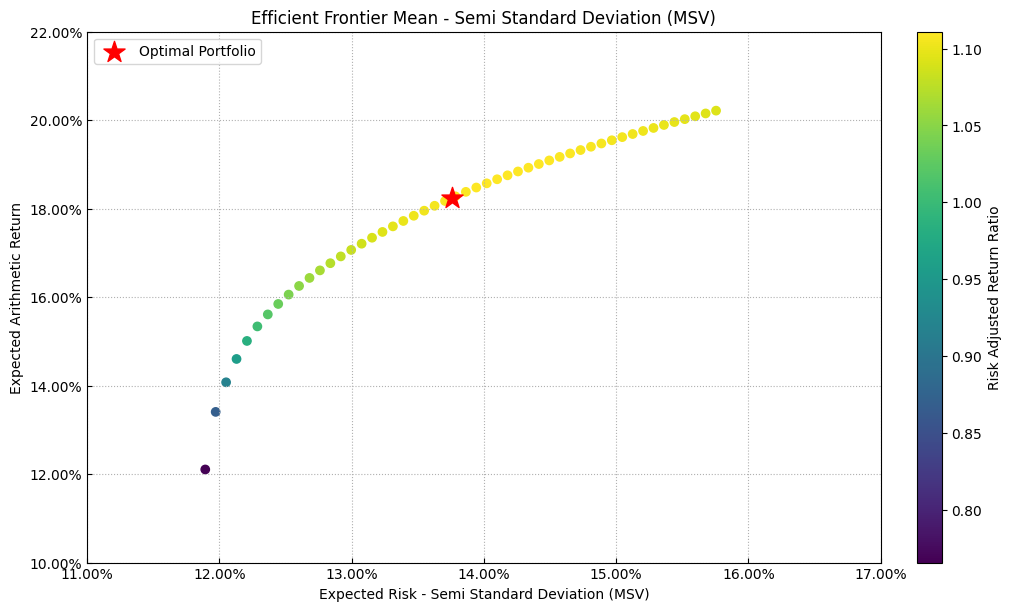

In [12]:
Respond("!plot frontier")

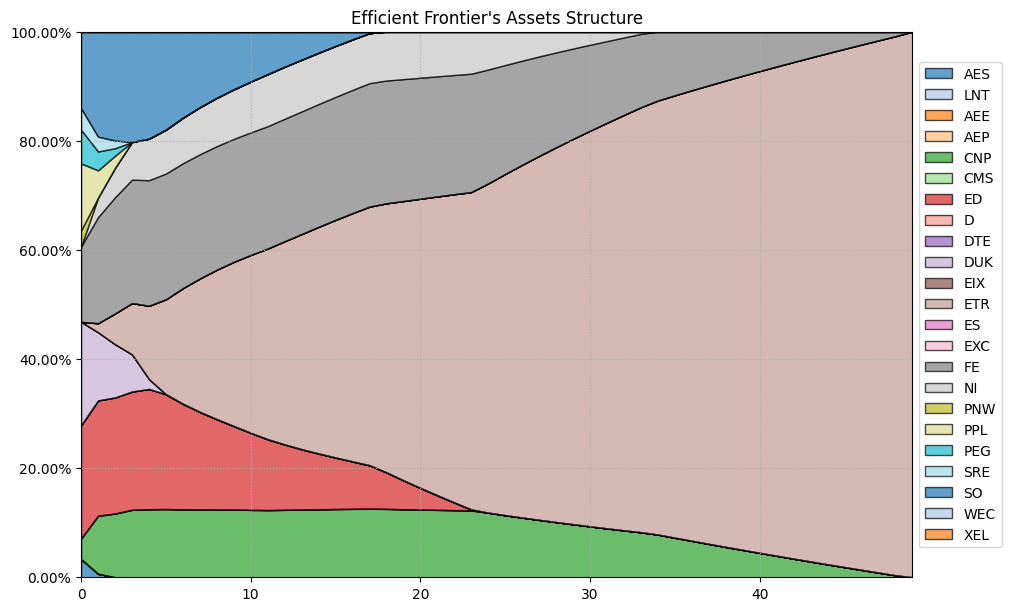

In [13]:
Respond("!plot frontier area")